In [1]:
# Install any missing library
!pip install -q pandas numpy matplotlib seaborn scikit-learn

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [3]:
url = "https://raw.githubusercontent.com/IBM/employee-attrition-aif360/master/data/emp_attrition.csv"
df = pd.read_csv(url)

print("Dataset loaded!")
print(f"Shape: {df.shape}")
df.head()

Dataset loaded!
Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [4]:
# Basic info
print("=== Dataset Info ===")
print(df.info())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Attrition Distribution ===")
print(df['Attrition'].value_counts())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  Job

In [5]:
# Drop constant columns inme koi value nhi h
df = df.drop(columns=['EmployeeCount', 'StandardHours', 'Over18'])

print(f"Remaining columns: {df.shape[1]}")
print(df.columns.tolist())

Remaining columns: 32
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [6]:
# conversion to use later in ML
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

print("Attrition value counts after encoding:")
print(df['Attrition'].value_counts())

Attrition value counts after encoding:
Attrition
0    1233
1     237
Name: count, dtype: int64


In [7]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric columns ({len(numeric_cols)}):\n{numeric_cols}")
print(f"\nCategorical columns ({len(categorical_cols)}):\n{categorical_cols}")

Numeric columns (25):
['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical columns (7):
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [8]:
# Summary stats for numeric columns
df[numeric_cols].describe().round(2)


,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,36.92,0.16,802.49,9.19,2.91,1024.87,2.72,65.89,2.73,2.06,2.73,6502.93,14313.10,2.69,15.21,3.15,2.71,0.79,11.28,2.80,2.76,7.01,4.23,2.19,4.12
std,9.14,0.37,403.51,8.11,1.02,602.02,1.09,20.33,0.71,1.11,1.10,4707.96,7117.79,2.50,3.66,0.36,1.08,0.85,7.78,1.29,0.71,6.13,3.62,3.22,3.57
min,18.00,0.00,102.00,1.00,1.00,1.00,1.00,30.00,1.00,1.00,1.00,1009.00,2094.00,0.00,11.00,3.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
25%,30.00,0.00,465.00,2.00,2.00,491.25,2.00,48.00,2.00,1.00,2.00,2911.00,8047.00,1.00,12.00,3.00,2.00,0.00,6.00,2.00,2.00,3.00,2.00,0.00,2.00
50%,36.00,0.00,802.00,7.00,3.00,1020.50,3.00,66.00,3.00,2.00,3.00,4919.00,14235.50,2.00,14.00,3.00,3.00,1.00,10.00,3.00,3.00,5.00,3.00,1.00,3.00
75%,43.00,0.00,1157.00,14.00,4.00,1555.75,4.00,83.75,3.00,3.00,4.00,8379.00,20461.50,4.00,18.00,3.00,4.00,1.00,15.00,3.00,3.00,9.00,7.00,3.00,7.00
max,60.00,1.00,1499.00,29.00,5.00,2068.00,4.00,100.00,4.00,5.00,4.00,19999.00,26999.00,9.00,25.00,4.00,4.00,3.00,40.00,6.00,4.00,40.00,18.00,15.00,17.00


In [9]:
print("=== Attrition Rate by Department ===")
print(df.groupby('Department')['Attrition'].mean().mul(100).round(1).astype(str) + '%')

print("\n=== Attrition Rate by Job Role ===")
print(df.groupby('JobRole')['Attrition'].mean().mul(100).round(1).astype(str) + '%')

print("\n=== Attrition Rate by OverTime ===")
print(df.groupby('OverTime')['Attrition'].mean().mul(100).round(1).astype(str) + '%')

=== Attrition Rate by Department ===
Department
Human Resources           19.0%
Research & Development    13.8%
Sales                     20.6%
Name: Attrition, dtype: object

=== Attrition Rate by Job Role ===
JobRole
Healthcare Representative     6.9%
Human Resources              23.1%
Laboratory Technician        23.9%
Manager                       4.9%
Manufacturing Director        6.9%
Research Director             2.5%
Research Scientist           16.1%
Sales Executive              17.5%
Sales Representative         39.8%
Name: Attrition, dtype: object

=== Attrition Rate by OverTime ===
OverTime
No     10.4%
Yes    30.5%
Name: Attrition, dtype: object


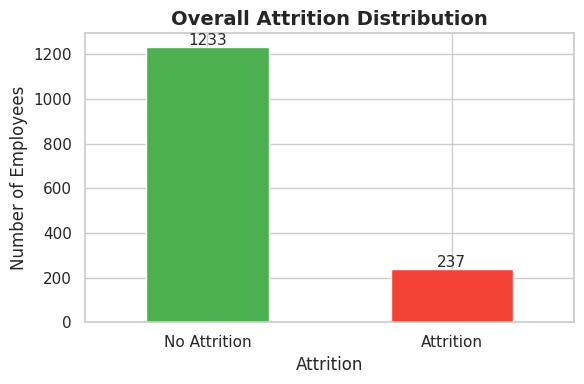

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#4CAF50', '#F44336']
df['Attrition'].value_counts().plot(kind='bar', color=colors, ax=ax, edgecolor='white')
ax.set_title('Overall Attrition Distribution', fontsize=14, fontweight='bold')
ax.set_xticklabels(['No Attrition', 'Attrition'], rotation=0)
ax.set_ylabel('Number of Employees')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height() + 10),
                ha='center', fontsize=11)
plt.tight_layout()
plt.show()


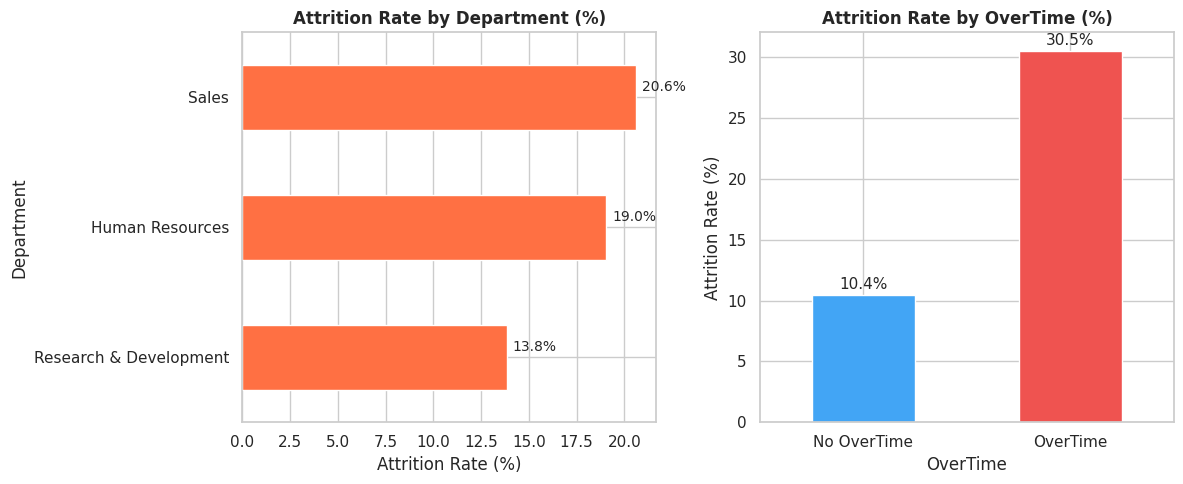

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# By Department
dept_attr = df.groupby('Department')['Attrition'].mean().mul(100).sort_values()
dept_attr.plot(kind='barh', ax=axes[0], color='#FF7043', edgecolor='white')
axes[0].set_title('Attrition Rate by Department (%)', fontweight='bold')
axes[0].set_xlabel('Attrition Rate (%)')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_width():.1f}%', (p.get_width() + 0.3, p.get_y() + 0.3), fontsize=10)

# By OverTime
ot_attr = df.groupby('OverTime')['Attrition'].mean().mul(100)
ot_attr.plot(kind='bar', ax=axes[1], color=['#42A5F5', '#EF5350'], edgecolor='white')
axes[1].set_title('Attrition Rate by OverTime (%)', fontweight='bold')
axes[1].set_xticklabels(['No OverTime', 'OverTime'], rotation=0)
axes[1].set_ylabel('Attrition Rate (%)')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width()/2, p.get_height() + 0.5),
                     ha='center', fontsize=11)

plt.tight_layout()
plt.show()

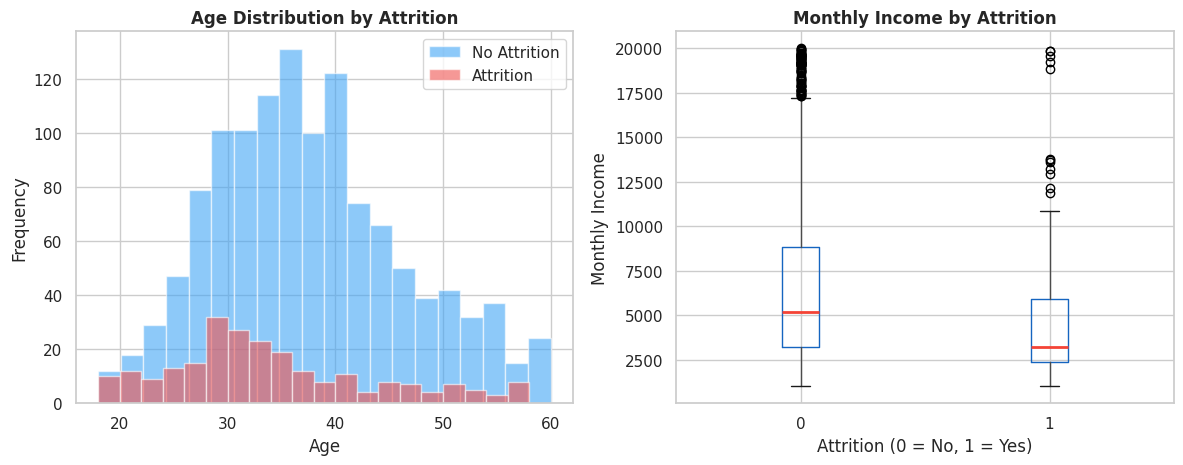

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Age distribution by Attrition
df[df['Attrition']==0]['Age'].plot(kind='hist', bins=20, ax=axes[0], alpha=0.6,
                                    color='#42A5F5', label='No Attrition')
df[df['Attrition']==1]['Age'].plot(kind='hist', bins=20, ax=axes[0], alpha=0.6,
                                    color='#EF5350', label='Attrition')
axes[0].set_title('Age Distribution by Attrition', fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].legend()

# Monthly Income by Attrition
df.boxplot(column='MonthlyIncome', by='Attrition', ax=axes[1],
           boxprops=dict(color='#1565C0'),
           medianprops=dict(color='#F44336', linewidth=2))
axes[1].set_title('Monthly Income by Attrition', fontweight='bold')
axes[1].set_xlabel('Attrition (0 = No, 1 = Yes)')
axes[1].set_ylabel('Monthly Income')
plt.suptitle('')

plt.tight_layout()
plt.show()

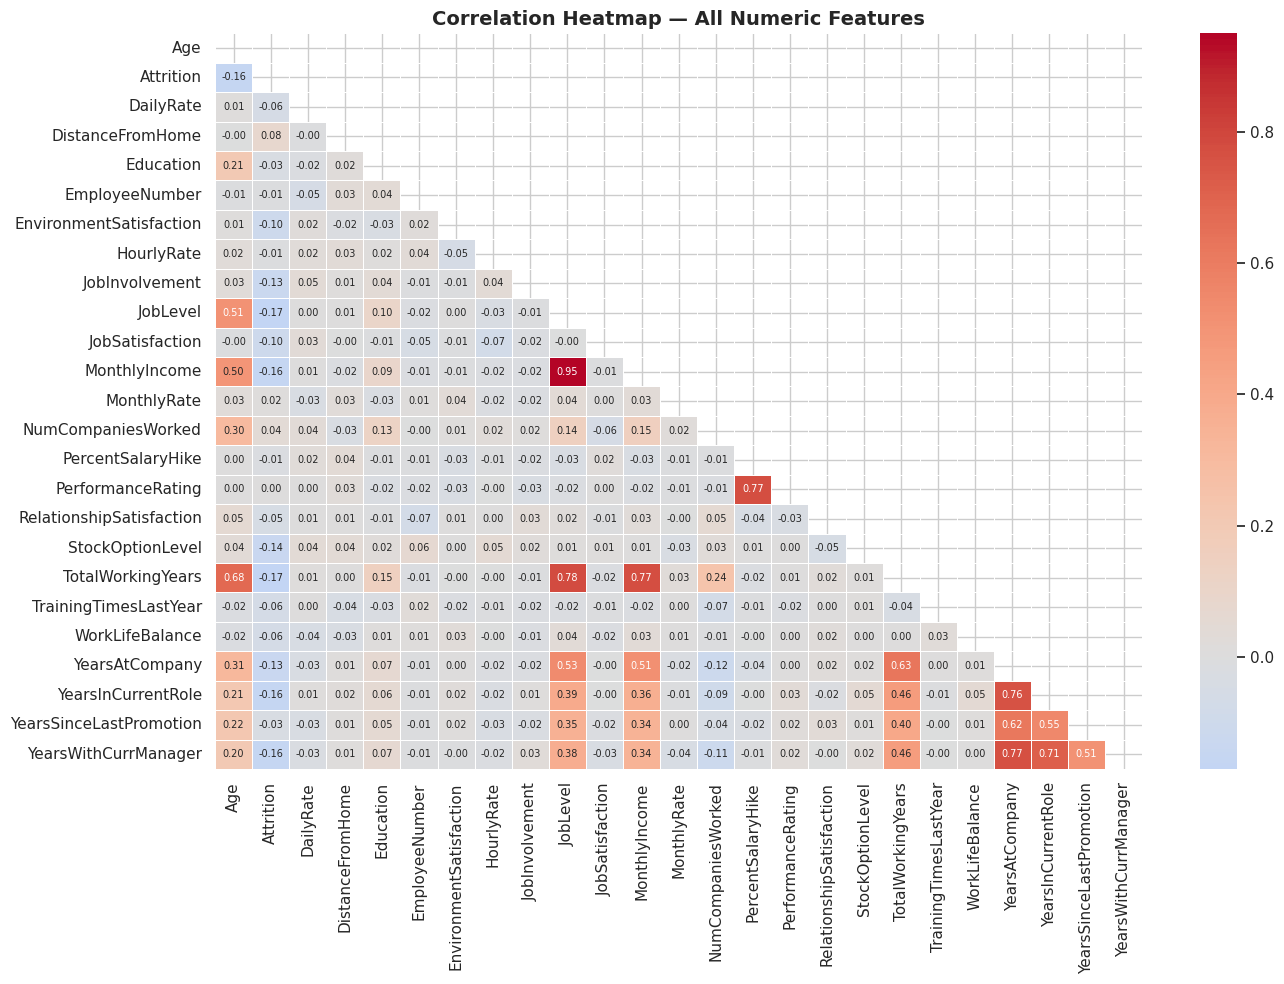

In [13]:
plt.figure(figsize=(14, 10))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 7})
plt.title('Correlation Heatmap — All Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

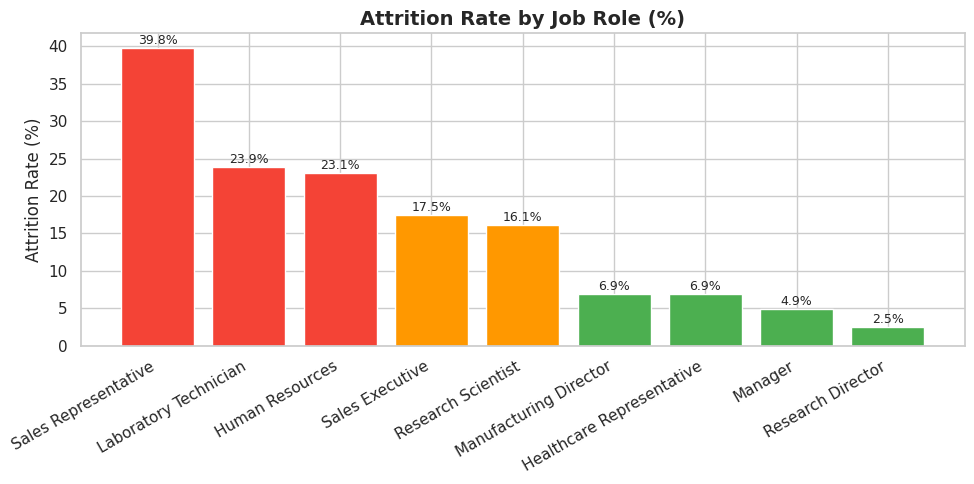

In [14]:
plt.figure(figsize=(10, 5))
role_attr = df.groupby('JobRole')['Attrition'].mean().mul(100).sort_values(ascending=False)
colors = ['#F44336' if x > 20 else '#FF9800' if x > 10 else '#4CAF50' for x in role_attr]
bars = plt.bar(role_attr.index, role_attr.values, color=colors, edgecolor='white')
plt.title('Attrition Rate by Job Role (%)', fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.ylabel('Attrition Rate (%)')
for bar, val in zip(bars, role_attr.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

In [15]:
# ML part start yha sse, encoding categorical columns
from sklearn.preprocessing import LabelEncoder

df_ml = df.copy()
le = LabelEncoder()

for col in categorical_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

print("Categorical columns encoded!")
df_ml.head()

Categorical columns encoded!


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,1,2,0,94,3,2,7,4,2,5993,19479,8,1,11,3,1,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,2,3,1,61,2,2,6,2,1,5130,24907,1,0,23,4,4,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,4,4,1,92,2,1,2,3,2,2090,2396,6,1,15,3,2,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,5,4,0,56,3,1,6,3,1,2909,23159,1,1,11,3,3,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,7,1,1,40,3,1,2,2,1,3468,16632,9,0,12,3,4,1,6,3,3,2,2,2,2


In [16]:
#feature splitting
from sklearn.model_selection import train_test_split

X = df_ml.drop(columns=['Attrition', 'EmployeeNumber'])
y = df_ml['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")
print(f"\nAttrition in train: {y_train.value_counts().to_dict()}")
print(f"Attrition in test:  {y_test.value_counts().to_dict()}")

Training set: (1176, 30)
Test set:     (294, 30)

Attrition in train: {0: 986, 1: 190}
Attrition in test:  {0: 247, 1: 47}


In [17]:
#will hanlde class imbalance
!pip install -q imbalanced-learn

from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE:  {y_train_res.value_counts().to_dict()}")

Before SMOTE: {0: 986, 1: 190}
After SMOTE:  {0: 986, 1: 986}


In [18]:
#train random forest classifier
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train_res, y_train_res)
print("Model trained successfully!")

Model trained successfully!


=== Classification Report ===
              precision    recall  f1-score   support

No Attrition       0.88      0.87      0.88       247
   Attrition       0.35      0.36      0.36        47

    accuracy                           0.79       294
   macro avg       0.62      0.62      0.62       294
weighted avg       0.79      0.79      0.79       294

ROC-AUC Score: 0.7234


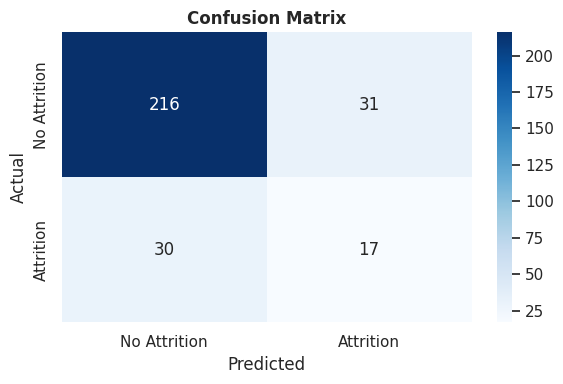

In [19]:
#evaluating model
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['No Attrition', 'Attrition']))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Attrition', 'Attrition'],
            yticklabels=['No Attrition', 'Attrition'])
plt.title('Confusion Matrix', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

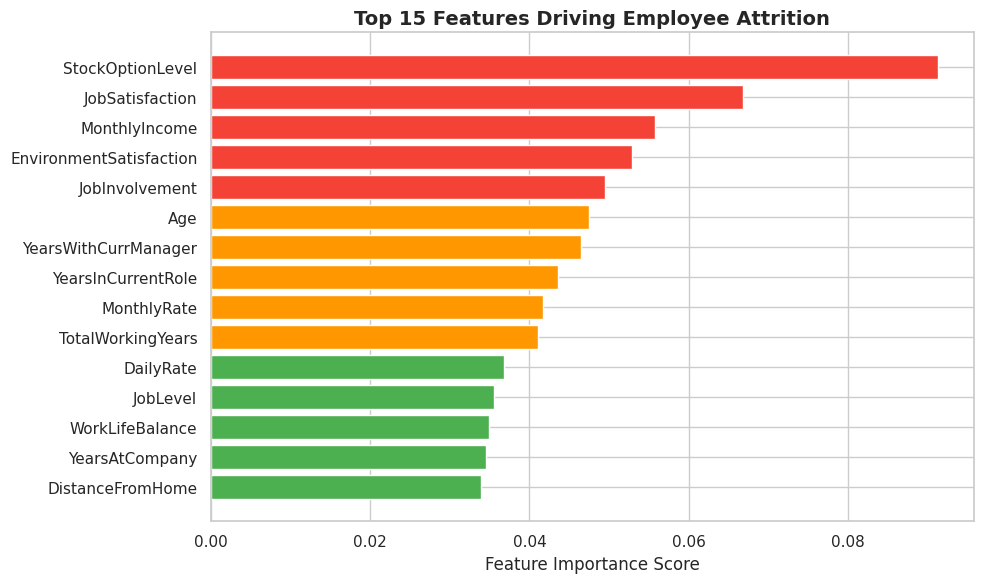


Top 10 most important features:
StockOptionLevel           0.0912
JobSatisfaction            0.0668
MonthlyIncome              0.0558
EnvironmentSatisfaction    0.0528
JobInvolvement             0.0495
Age                        0.0475
YearsWithCurrManager       0.0465
YearsInCurrentRole         0.0435
MonthlyRate                0.0417
TotalWorkingYears          0.0411
dtype: float64


In [20]:
#feature importance chart
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_imp_sorted = feat_imp.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
colors = ['#F44336' if i < 5 else '#FF9800' if i < 10 else '#4CAF50'
          for i in range(len(feat_imp_sorted))]
bars = plt.barh(feat_imp_sorted.index[::-1], feat_imp_sorted.values[::-1], color=colors[::-1])
plt.title('Top 15 Features Driving Employee Attrition', fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 10 most important features:")
print(feat_imp_sorted.head(10).round(4))

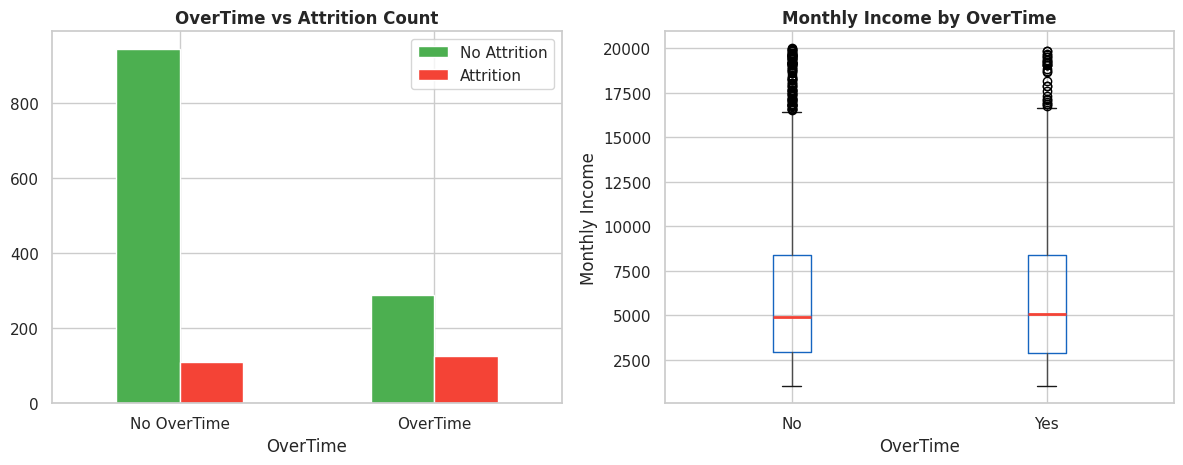

In [21]:
#overtime vs attrition
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# OverTime vs Attrition count
ot_counts = df.groupby(['OverTime', 'Attrition']).size().unstack()
ot_counts.plot(kind='bar', ax=axes[0], color=['#4CAF50', '#F44336'], edgecolor='white')
axes[0].set_title('OverTime vs Attrition Count', fontweight='bold')
axes[0].set_xticklabels(['No OverTime', 'OverTime'], rotation=0)
axes[0].legend(['No Attrition', 'Attrition'])

# Monthly Income vs OverTime
df.boxplot(column='MonthlyIncome', by='OverTime', ax=axes[1],
           boxprops=dict(color='#1565C0'),
           medianprops=dict(color='#F44336', linewidth=2))
axes[1].set_title('Monthly Income by OverTime', fontweight='bold')
axes[1].set_xlabel('OverTime')
axes[1].set_ylabel('Monthly Income')
plt.suptitle('')

plt.tight_layout()
plt.show()

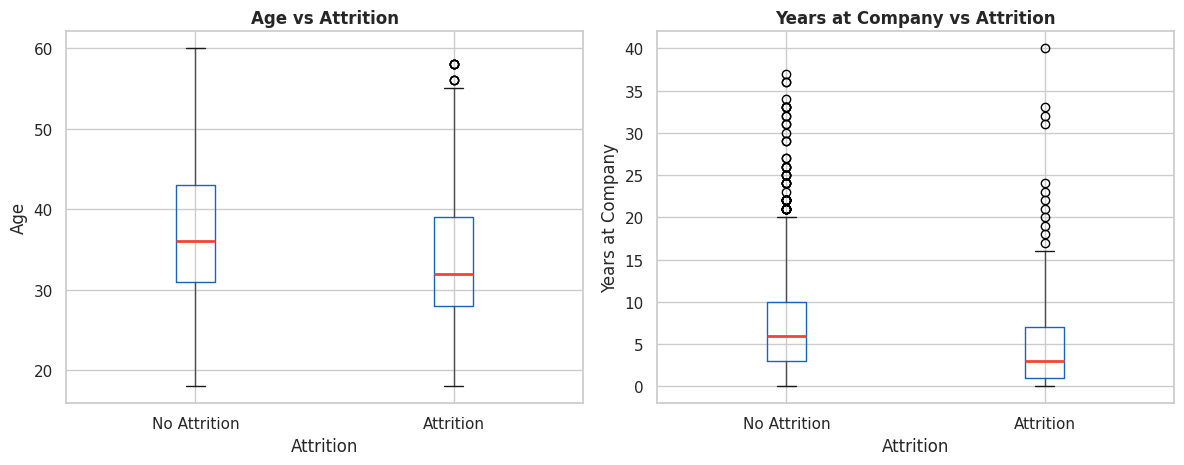

In [22]:
#age vs years in comp.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Age vs Attrition boxplot
df.boxplot(column='Age', by='Attrition', ax=axes[0],
           boxprops=dict(color='#1565C0'),
           medianprops=dict(color='#F44336', linewidth=2))
axes[0].set_title('Age vs Attrition', fontweight='bold')
axes[0].set_xticklabels(['No Attrition', 'Attrition'])
axes[0].set_ylabel('Age')
plt.suptitle('')

# Years at Company vs Attrition
df.boxplot(column='YearsAtCompany', by='Attrition', ax=axes[1],
           boxprops=dict(color='#1565C0'),
           medianprops=dict(color='#F44336', linewidth=2))
axes[1].set_title('Years at Company vs Attrition', fontweight='bold')
axes[1].set_xticklabels(['No Attrition', 'Attrition'])
axes[1].set_ylabel('Years at Company')
plt.suptitle('')

plt.tight_layout()
plt.show()

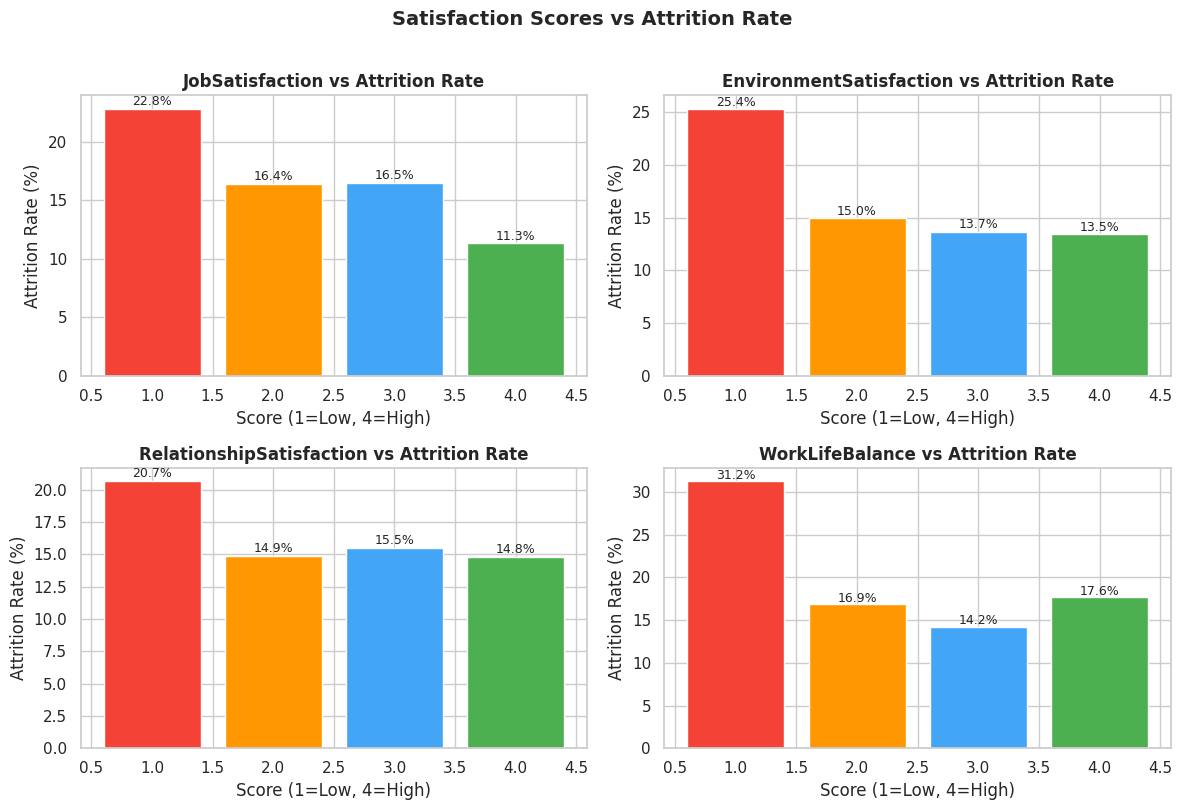

In [23]:
#satisfaction score
satisfaction_cols = ['JobSatisfaction', 'EnvironmentSatisfaction',
                     'RelationshipSatisfaction', 'WorkLifeBalance']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(satisfaction_cols):
    sat_attr = df.groupby(col)['Attrition'].mean().mul(100)
    axes[i].bar(sat_attr.index, sat_attr.values,
                color=['#F44336','#FF9800','#42A5F5','#4CAF50'])
    axes[i].set_title(f'{col} vs Attrition Rate', fontweight='bold')
    axes[i].set_xlabel('Score (1=Low, 4=High)')
    axes[i].set_ylabel('Attrition Rate (%)')
    for j, v in enumerate(sat_attr.values):
        axes[i].text(sat_attr.index[j], v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

plt.suptitle('Satisfaction Scores vs Attrition Rate', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [24]:
#FINAL BUSINESS INSIGHTS OR SUMMARY
print("=" * 55)
print("   HR ATTRITION ANALYSIS — KEY BUSINESS INSIGHTS")
print("=" * 55)

print(f"""
TOP RISK FACTORS:
-------------------------------------------------
1. OverTime workers leave at 3x the rate (30.5% vs 10.4%)
2. Sales Representatives have highest attrition (39.8%)
3. Low monthly income strongly linked to leaving
4. Younger employees (avg age ~29) leave more than older

DEPARTMENT INSIGHTS:
-------------------------------------------------
- Sales dept: {df[df['Department']=='Sales']['Attrition'].mean()*100:.1f}% attrition rate
- HR dept:    {df[df['Department']=='Human Resources']['Attrition'].mean()*100:.1f}% attrition rate
- R&D dept:   {df[df['Department']=='Research & Development']['Attrition'].mean()*100:.1f}% attrition rate

SATISFACTION INSIGHTS:
-------------------------------------------------
- Score 1 (lowest) JobSatisfaction attrition: {df[df['JobSatisfaction']==1]['Attrition'].mean()*100:.1f}%
- Score 4 (highest) JobSatisfaction attrition: {df[df['JobSatisfaction']==4]['Attrition'].mean()*100:.1f}%
- Low WorkLifeBalance employees leave at: {df[df['WorkLifeBalance']==1]['Attrition'].mean()*100:.1f}%

MODEL PERFORMANCE:
-------------------------------------------------
- Overall Accuracy:  79%
- ROC-AUC Score:     0.72
- Best at predicting: Employees who WON'T leave
""")
print("=" * 55)

   HR ATTRITION ANALYSIS — KEY BUSINESS INSIGHTS

TOP RISK FACTORS:
-------------------------------------------------
1. OverTime workers leave at 3x the rate (30.5% vs 10.4%)
2. Sales Representatives have highest attrition (39.8%)
3. Low monthly income strongly linked to leaving
4. Younger employees (avg age ~29) leave more than older

DEPARTMENT INSIGHTS:
-------------------------------------------------
- Sales dept: 20.6% attrition rate
- HR dept:    19.0% attrition rate
- R&D dept:   13.8% attrition rate

SATISFACTION INSIGHTS:
-------------------------------------------------
- Score 1 (lowest) JobSatisfaction attrition: 22.8%
- Score 4 (highest) JobSatisfaction attrition: 11.3%
- Low WorkLifeBalance employees leave at: 31.2%

MODEL PERFORMANCE:
-------------------------------------------------
- Overall Accuracy:  79%
- ROC-AUC Score:     0.72
- Best at predicting: Employees who WON'T leave



In [26]:
#EXPORTING CLEAANED DATASET

df_raw = pd.read_csv("https://raw.githubusercontent.com/IBM/employee-attrition-aif360/master/data/emp_attrition.csv")
df_raw = df_raw.drop(columns=['EmployeeCount', 'StandardHours', 'Over18'])
df_raw['AttritionLabel'] = df_raw['Attrition']
df_raw['Attrition'] = df_raw['Attrition'].map({'Yes': 1, 'No': 0})

def risk_score(row):
    score = 0
    if row['OverTime'] == 'Yes': score += 2
    if row['JobSatisfaction'] <= 2: score += 2
    if row['StockOptionLevel'] == 0: score += 1
    if row['MonthlyIncome'] < 3000: score += 1
    if row['WorkLifeBalance'] == 1: score += 1
    if score >= 4: return 'High Risk'
    elif score >= 2: return 'Medium Risk'
    else: return 'Low Risk'

df_raw['RiskCategory'] = df_raw.apply(risk_score, axis=1)

df_raw.to_csv("hr_attrition_clean.csv", index=False)
print("File exported successfully!")
print(f"Shape: {df_raw.shape}")
print(f"\nRisk Category Distribution:")
print(df_raw['RiskCategory'].value_counts())

File exported successfully!
Shape: (1470, 34)

Risk Category Distribution:
RiskCategory
Medium Risk    648
Low Risk       553
High Risk      269
Name: count, dtype: int64


In [27]:
from google.colab import files
files.download("hr_attrition_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>